# Notebook 4: Medical Interpretation of Symptom Clusters
## Healthcare Symptom Pattern Discovery — Task 4
**Objective:** Interpret each discovered cluster from a clinical standpoint —
identify dominant symptom signatures, map clusters to health-risk categories,
produce radar charts, and generate a clinical summary table.

**Input :** `task3_viz_data.csv`  
**Output:** `task4_interpreted.csv` + `task4_clinical_summary.csv` → fed into Notebook 5


In [11]:
# ── Imports ─────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings, textwrap
warnings.filterwarnings('ignore')

np.random.seed(42)
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 110
print("Setup complete.")


Setup complete.


In [12]:
# ── Load data from Notebook 3 ────────────────────────────────────────────────
df = pd.read_csv('..//Result_NB3/task3_viz_data.csv', index_col=0)
print(f"Loaded shape: {df.shape}")

meta_cols = ['Disease','hc_cluster','gmm_cluster','gmm_confidence',
             'pca_1','pca_2','pca_3','tsne_1','tsne_2']
symptom_cols = [c for c in df.columns if c not in meta_cols]

X           = df[symptom_cols].astype(float)
hc_labels   = df['hc_cluster'].values
disease_lbl = df['Disease']
n_clusters  = len(np.unique(hc_labels))

print(f"Symptom features: {len(symptom_cols)}")
print(f"Clusters: {n_clusters}")


Loaded shape: (4920, 166)
Symptom features: 157
Clusters: 41


In [13]:
# ── Compute per-cluster symptom presence rates ───────────────────────────────
# cluster_mean[k][symptom] = fraction of patients in cluster k who have that symptom.
# This is the primary input for medical interpretation.

cluster_df   = pd.DataFrame(X.values, columns=symptom_cols)
cluster_df['cluster'] = hc_labels
cluster_mean = cluster_df.groupby('cluster').mean()

print("=== Cluster mean matrix shape:", cluster_mean.shape)
print("(Each cell = mean symptom presence rate for that cluster)")
print(cluster_mean.head())


=== Cluster mean matrix shape: (41, 157)
(Each cell = mean symptom presence rate for that cluster)
         abnormal_menstruation  acidity  acute_liver_failure  \
cluster                                                        
1                          0.0      0.0                  0.0   
2                          1.0      0.0                  0.0   
3                          0.0      0.0                  0.0   
4                          0.0      0.0                  0.0   
5                          1.0      0.0                  0.0   

         altered_sensorium  anxiety  back_pain  belly_pain  blackheads  \
cluster                                                                  
1                      0.0     0.00        0.0         0.0         0.0   
2                      0.0     0.00        0.0         0.0         0.0   
3                      0.0     0.95        0.0         0.0         0.0   
4                      0.0     0.00        0.0         0.0         0.0   
5       

In [14]:
# ── Top 10 symptoms per cluster ───────────────────────────────────────────────
# The top-10 symptoms by mean presence rate are the 'defining features'
# of that cluster — they drive the medical interpretation.

cluster_top_symptoms = {}
print("=== Top 10 Symptoms per Cluster ===\n")
for k in sorted(cluster_mean.index):
    top10 = cluster_mean.loc[k].nlargest(10).index.tolist()
    cluster_top_symptoms[k] = top10
    rates = cluster_mean.loc[k][top10].round(3).tolist()
    print(f"Cluster {k}:")
    for sym, rate in zip(top10, rates):
        print(f"  {sym:<45} {rate:.3f}")
    print()


=== Top 10 Symptoms per Cluster ===

Cluster 1:
  pca_6                                         4.296
  pca_7                                         4.139
  pca_14                                        1.407
  chest_pain                                    1.000
  congestion                                    1.000
  loss_of_smell                                 1.000
  muscle_pain                                   1.000
  phlegm                                        1.000
  redness_of_eyes                               1.000
  runny_nose                                    1.000

Cluster 2:
  pca_8                                         1.330
  pca_6                                         1.097
  abnormal_menstruation                         1.000
  brittle_nails                                 1.000
  depression                                    1.000
  enlarged_thyroid                              1.000
  irritability                                  1.000
  swollen_extremeties 

In [15]:
# ── Dominant disease and cluster purity ─────────────────────────────────────
# For each cluster, identify: (a) the most common disease, (b) its prevalence %.
# High purity → the cluster captures a clinically coherent group.

cluster_dominant = {}
cluster_purity   = {}

for k in sorted(np.unique(hc_labels)):
    dis_k    = disease_lbl[hc_labels == k]
    dominant = dis_k.mode()[0]
    purity   = (dis_k == dominant).mean() * 100
    cluster_dominant[k] = dominant
    cluster_purity[k]   = purity

cluster_sizes = pd.Series(hc_labels).value_counts().sort_index()

print(f"{'Clust':>6} | {'Size':>5} | {'Dominant Disease':<40} | {'Purity%':>7}")
print("-" * 70)
for k in sorted(cluster_dominant.keys()):
    print(f"  {k:>4} | {int(cluster_sizes[k]):>5} | "
          f"{cluster_dominant[k]:<40} | {cluster_purity[k]:>6.1f}%")


 Clust |  Size | Dominant Disease                         | Purity%
----------------------------------------------------------------------
     1 |   120 | Common Cold                              |  100.0%
     2 |   120 | Hypothyroidism                           |  100.0%
     3 |   120 | Hypoglycemia                             |  100.0%
     4 |   120 | Diabetes                                 |  100.0%
     5 |   120 | Hyperthyroidism                          |  100.0%
     6 |   120 | Migraine                                 |  100.0%
     7 |   120 | Tuberculosis                             |  100.0%
     8 |   120 | Pneumonia                                |  100.0%
     9 |   120 | Typhoid                                  |  100.0%
    10 |   120 | Chicken pox                              |  100.0%
    11 |   120 | Dengue                                   |  100.0%
    12 |   120 | Hepatitis B                              |  100.0%
    13 |   120 | Hepatitis E                 

In [16]:
# ── Assign health-risk category labels ───────────────────────────────────────
# Rule-based heuristic: we inspect the top symptom set for each cluster and
# map it to a clinically recognisable risk category.
# Rules are applied in priority order; the FIRST match wins.

def assign_risk(top_syms):
    s = set(top_syms)
    if s & {'yellowish_skin','dark_urine','yellowing_of_eyes','acute_liver_failure'}:
        return 'Hepatic / Jaundice Risk'
    if s & {'cough','breathlessness','phlegm','mucoid_sputum','blood_in_sputum','rusty_sputum'}:
        return 'Respiratory Risk'
    if s & {'vomiting','diarrhoea','stomach_pain','abdominal_pain','nausea','indigestion'}:
        return 'Gastrointestinal Risk'
    if s & {'itching','skin_rash','nodal_skin_eruptions','pus_filled_pimples','blister'}:
        return 'Dermatological Risk'
    if s & {'headache','dizziness','loss_of_balance','altered_sensorium','stiff_neck'}:
        return 'Neurological Risk'
    if s & {'weight_loss','weight_gain','fatigue','lethargy','polyuria','excessive_hunger'}:
        return 'Metabolic / Endocrine Risk'
    if s & {'joint_pain','muscle_pain','back_pain','neck_pain','knee_pain','swelling_joints'}:
        return 'Musculoskeletal Risk'
    if s & {'high_fever','chills','sweating','malaise','swelled_lymph_nodes'}:
        return 'Febrile / Infectious Risk'
    return 'General / Mixed Risk'

risk_labels = {k: assign_risk(cluster_top_symptoms[k]) for k in sorted(np.unique(hc_labels))}

print(f"{'Cluster':>8} | {'Risk Category'}")
print("-" * 45)
for k, r in risk_labels.items():
    print(f"  {k:>6} | {r}")


 Cluster | Risk Category
---------------------------------------------
       1 | Respiratory Risk
       2 | Neurological Risk
       3 | Metabolic / Endocrine Risk
       4 | Metabolic / Endocrine Risk
       5 | General / Mixed Risk
       6 | General / Mixed Risk
       7 | Respiratory Risk
       8 | General / Mixed Risk
       9 | Febrile / Infectious Risk
      10 | Neurological Risk
      11 | Musculoskeletal Risk
      12 | Hepatic / Jaundice Risk
      13 | General / Mixed Risk
      14 | Metabolic / Endocrine Risk
      15 | General / Mixed Risk
      16 | Gastrointestinal Risk
      17 | Dermatological Risk
      18 | Dermatological Risk
      19 | General / Mixed Risk
      20 | Gastrointestinal Risk
      21 | Neurological Risk
      22 | Neurological Risk
      23 | Febrile / Infectious Risk
      24 | Gastrointestinal Risk
      25 | Respiratory Risk
      26 | Febrile / Infectious Risk
      27 | Gastrointestinal Risk
      28 | Respiratory Risk
      29 | Gastrointest

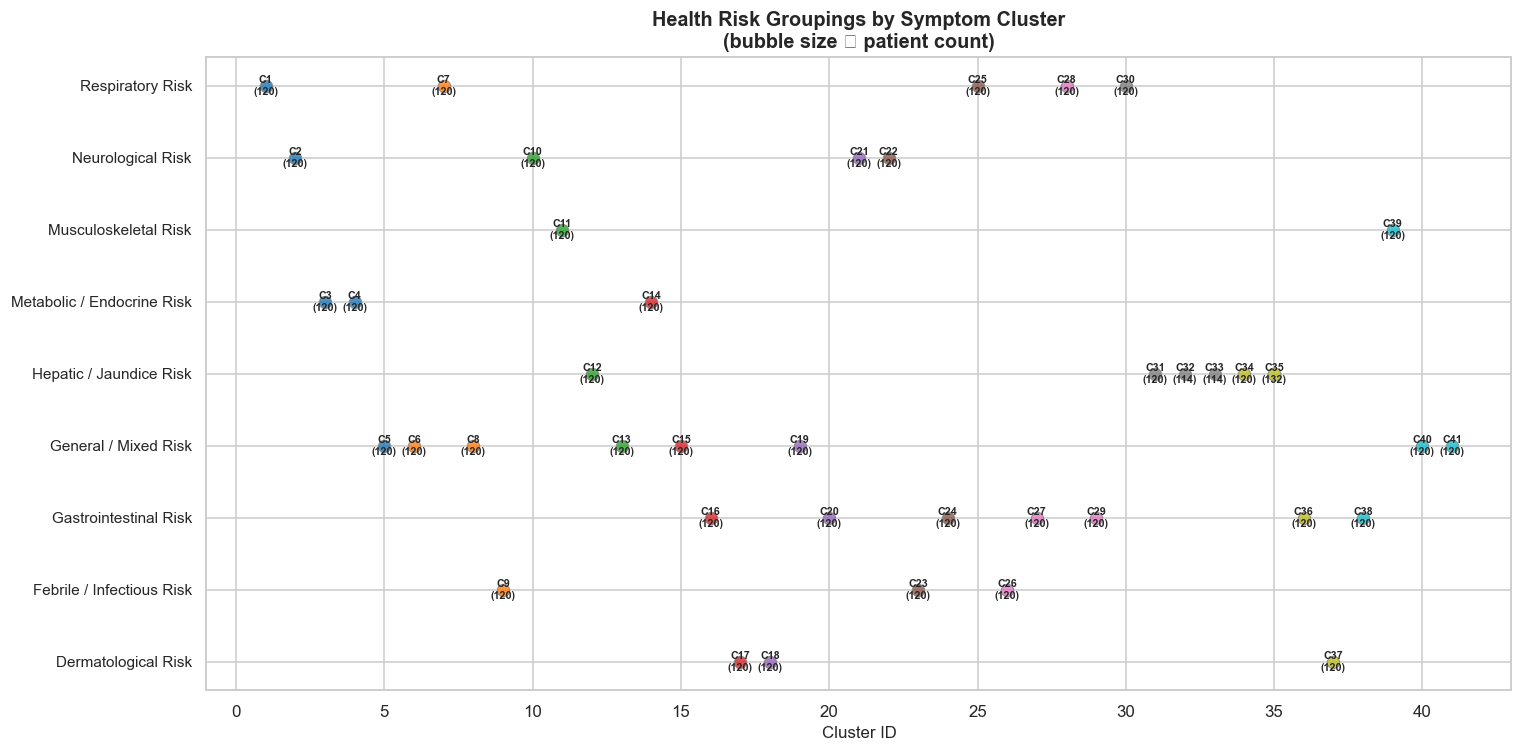

Saved → Result_NB4/task4_risk_bubble_chart.png


In [17]:
# ── Figure 1: Health Risk Grouping Bubble Chart ──────────────────────────────
# Bubble size proportional to cluster population.
# Y-axis = risk category; X-axis = cluster ID.

risk_order = sorted(set(risk_labels.values()))
y_map = {r: i for i, r in enumerate(risk_order)}

fig, ax = plt.subplots(figsize=(14, 7))
for k in risk_labels:
    rc   = risk_labels[k]
    sz   = int(cluster_sizes[k])
    ax.scatter(k, y_map[rc], s=sz*0.55,
               c=plt.cm.tab10(list(risk_labels.keys()).index(k) / n_clusters),
               alpha=0.8, edgecolors='grey', linewidths=0.7)
    ax.annotate(f"C{k}\n({sz})", (k, y_map[rc]),
                ha='center', va='center', fontsize=7, fontweight='bold')

ax.set_yticks(range(len(risk_order)))
ax.set_yticklabels(risk_order, fontsize=10)
ax.set_xlabel('Cluster ID', fontsize=11)
ax.set_title('Health Risk Groupings by Symptom Cluster\n(bubble size ∝ patient count)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('..//Result_NB4/task4_risk_bubble_chart.png', bbox_inches='tight')
plt.show()
print("Saved → Result_NB4/task4_risk_bubble_chart.png")


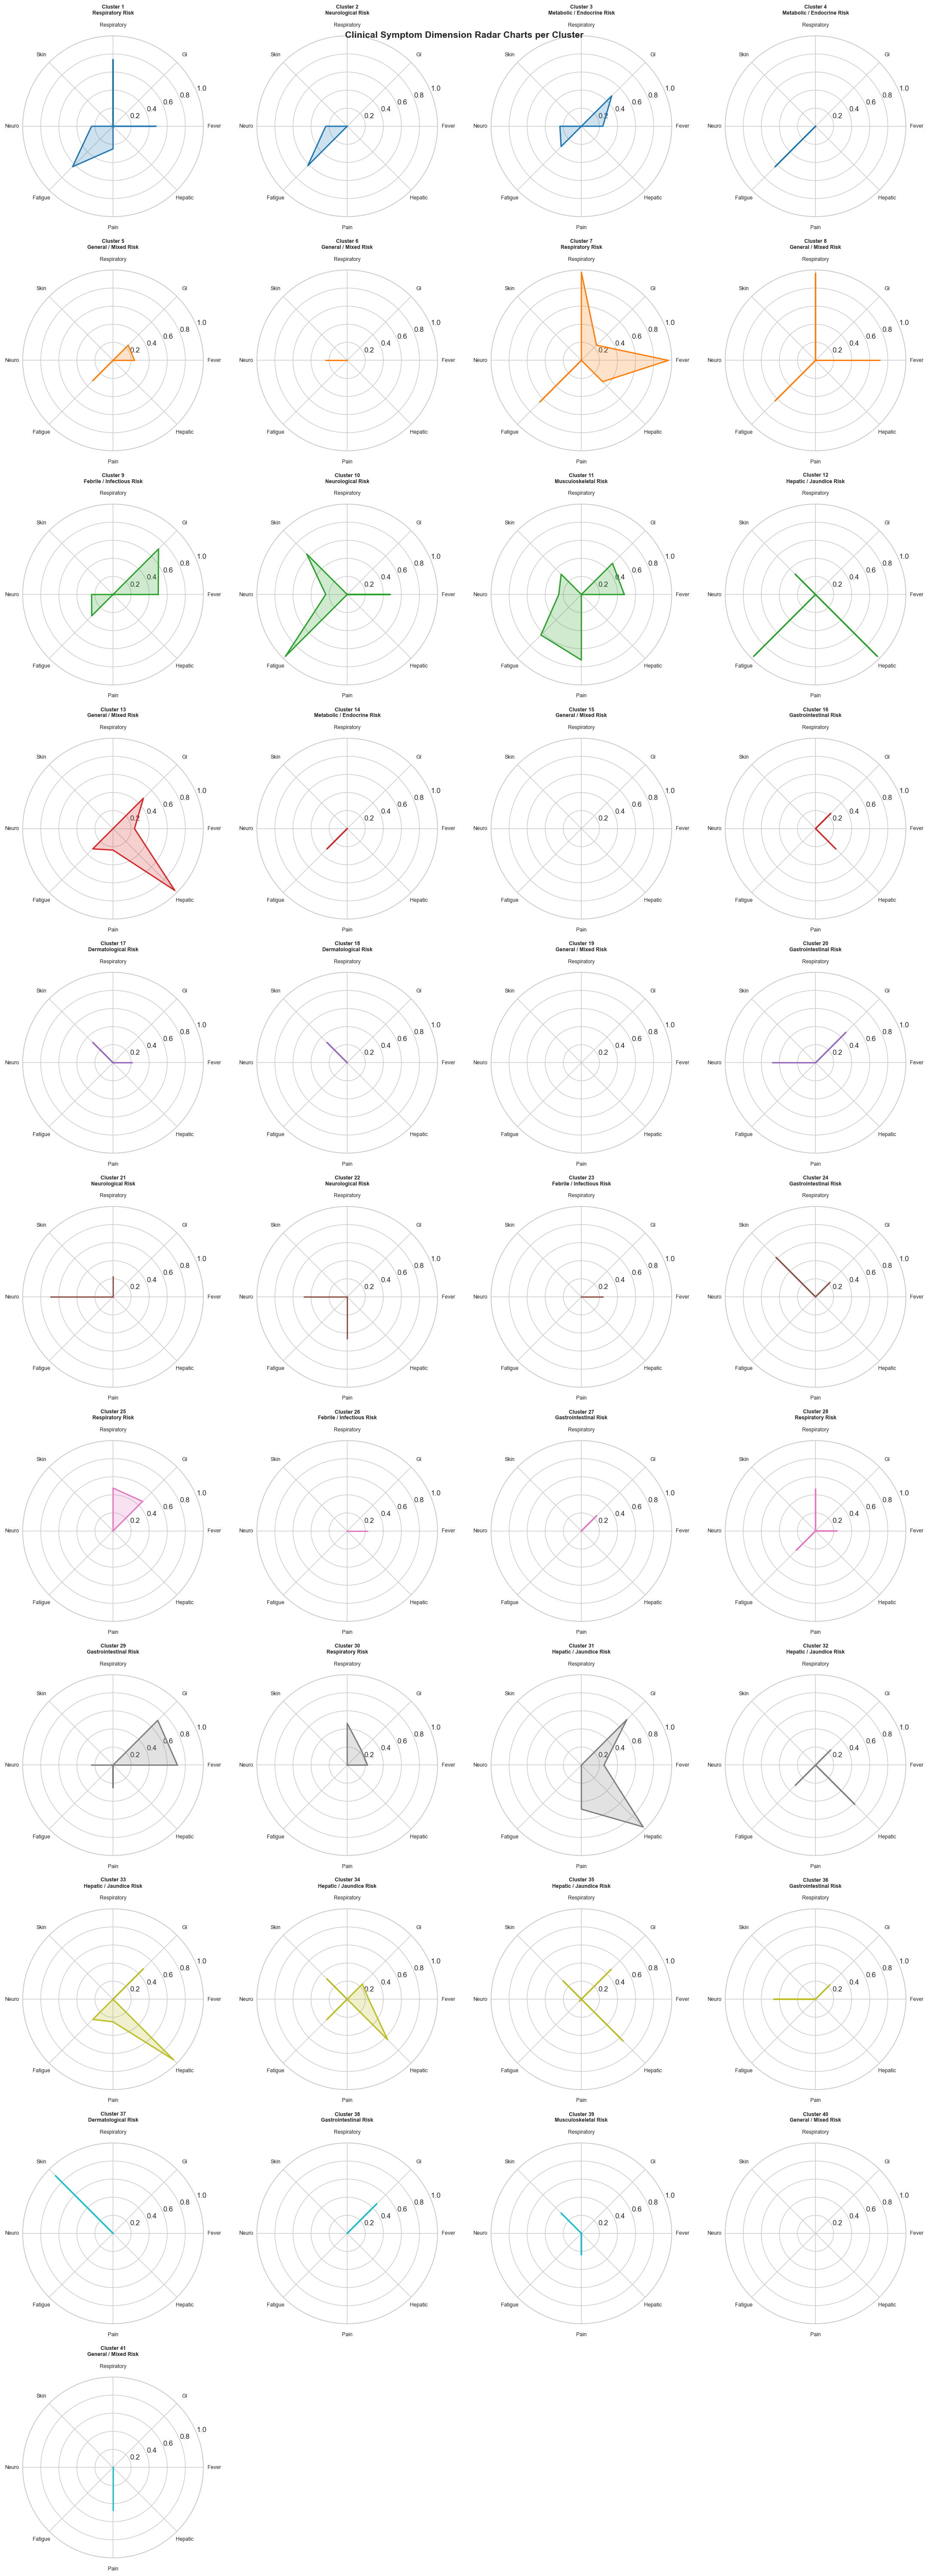

Saved → Result_NB4/task4_radar_charts.png


In [18]:
# ── Figure 2: Radar / Spider Charts per Cluster ─────────────────────────────
# Each cluster is profiled across 8 clinical dimensions.
# The radar chart gives clinicians an intuitive overview of each cluster's
# symptom signature without needing to inspect all 130 binary columns.

dimensions = {
    'Fever':       ['high_fever','mild_fever','chills','sweating'],
    'GI':          ['vomiting','nausea','diarrhoea','stomach_pain','abdominal_pain'],
    'Respiratory': ['cough','breathlessness','phlegm','chest_pain'],
    'Skin':        ['itching','skin_rash','nodal_skin_eruptions'],
    'Neuro':       ['headache','dizziness','altered_sensorium','loss_of_balance'],
    'Fatigue':     ['fatigue','lethargy','malaise'],
    'Pain':        ['joint_pain','muscle_pain','back_pain','neck_pain'],
    'Hepatic':     ['yellowish_skin','dark_urine','yellowing_of_eyes']
}

def dim_score(row, cols):
    present = [c for c in cols if c in row.index]
    return float(row[present].mean()) if present else 0.0

dim_names = list(dimensions.keys())
angles = np.linspace(0, 2*np.pi, len(dim_names), endpoint=False).tolist()
angles += angles[:1]  # close polygon

nk    = len(cluster_mean)
ncols = min(4, nk)
nrows = (nk + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 5*nrows),
                          subplot_kw=dict(polar=True))
axes_flat = np.array(axes).flatten()
colors = plt.cm.tab10(np.linspace(0, 1, nk))

for idx, k in enumerate(sorted(cluster_mean.index)):
    ax = axes_flat[idx]
    vals = [dim_score(cluster_mean.loc[k], dimensions[d]) for d in dim_names]
    vals += vals[:1]
    ax.plot(angles, vals, color=colors[idx], linewidth=2)
    ax.fill(angles, vals, color=colors[idx], alpha=0.22)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(dim_names, fontsize=8)
    ax.set_ylim(0, 1)
    ax.set_title(f"Cluster {k}\n{risk_labels[k]}", fontsize=8, fontweight='bold', pad=12)

for j in range(nk, len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.suptitle('Clinical Symptom Dimension Radar Charts per Cluster',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('..//Result_NB4/task4_radar_charts.png', bbox_inches='tight')
plt.show()
print("Saved → Result_NB4/task4_radar_charts.png")


In [19]:
# ── Clinical Summary Table ────────────────────────────────────────────────────
summary_rows = []
for k in sorted(np.unique(hc_labels)):
    summary_rows.append({
        'Cluster':          k,
        'Size':             int(cluster_sizes[k]),
        'Risk Category':    risk_labels[k],
        'Top 5 Symptoms':   ', '.join(cluster_top_symptoms[k][:5]),
        'Dominant Disease': cluster_dominant[k],
        'Purity (%)':       round(cluster_purity[k], 1)
    })

summary_df = pd.DataFrame(summary_rows)
pd.set_option('display.max_colwidth', 55)
print("=== Clinical Summary Table ===")
display(summary_df)


=== Clinical Summary Table ===


,Cluster,Size,Risk Category,Top 5 Symptoms,Dominant Disease,Purity (%)
0,1,120,Respiratory Risk,"pca_6, pca_7, pca_14, chest_pain, congestion",Common Cold,100.0
1,2,120,Neurological Risk,"pca_8, pca_6, abnormal_menstruation, brittle_nails,...",Hypothyroidism,100.0
2,3,120,Metabolic / Endocrine Risk,"pca_4, pca_7, pca_8, pca_12, pca_14",Hypoglycemia,100.0
3,4,120,Metabolic / Endocrine Risk,"pca_4, pca_5, pca_10, pca_11, pca_7",Diabetes,100.0
4,5,120,General / Mixed Risk,"pca_20, pca_16, pca_4, pca_15, pca_11",Hyperthyroidism,100.0
5,6,120,General / Mixed Risk,"pca_13, pca_4, pca_27, pca_22, pca_17",Migraine,100.0
6,7,120,Respiratory Risk,"pca_5, pca_24, pca_9, pca_21, pca_27",Tuberculosis,100.0
7,8,120,General / Mixed Risk,"pca_30, pca_9, pca_22, pca_29, pca_28",Pneumonia,100.0
8,9,120,Febrile / Infectious Risk,"pca_16, pca_10, pca_8, pca_22, pca_11",Typhoid,100.0
9,10,120,Neurological Risk,"pca_5, pca_7, pca_17, pca_24, pca_8",Chicken pox,100.0


In [20]:
# ── Save outputs ─────────────────────────────────────────────────────────────
df['risk_category'] = pd.Series(hc_labels, index=df.index).map(risk_labels).values
summary_df.to_csv('..//Result_NB4/task4_clinical_summary.csv', index=False)
df.to_csv('..//Result_NB4/task4_interpreted.csv')

print("✅ Saved: Result_NB4/task4_clinical_summary.csv")
print("✅ Saved: Result_NB4/task4_interpreted.csv")
print("\n→ Next step: Run Notebook 5 (Ethics, Limitations & Final Report)")


✅ Saved: Result_NB4/task4_clinical_summary.csv
✅ Saved: Result_NB4/task4_interpreted.csv

→ Next step: Run Notebook 5 (Ethics, Limitations & Final Report)
